# Ground-Truth-Evaluation: Modell vs. manuelle Bewertung

Reproduzierbarer Vergleich der Prototyp-Scores gegen eine manuell bewertete Referenzstichprobe.
Logik in `src/evaluation/ground_truth.py`, Konzept in `docs/methodik_evaluation_ground_truth`.

**Ablauf:**
1. Modell auf der Stichprobe scoren (Testergebnisse).
2. Gefülltes Bewertungs-Template (`ground_truth_template.csv`, 0–3 je Dimension) laden.
3. Mergen, Modell-Urteil per gleicher Regel ableiten.
4. Kennzahlen (Spearman, Kendall τ, Accuracy, Cohen's κ, gewichtetes κ, Konfusion).
5. Thesis-Grafiken erzeugen.

> **Vor dem Lauf:** die 0–3-Spalten (`gt_findability`, `gt_accessibility`, `gt_reusability`, `gt_expressiveness`) im Template ausfüllen — **blind** gegenüber den Modell-Scores.

In [ ]:
from datetime import datetime
import sys
from pathlib import Path

# Repo-Root robust finden (egal von wo das Notebook startet).
REPO = Path.cwd()
while not (REPO / 'src').exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO / 'src'))

from dotenv import load_dotenv
load_dotenv(REPO / '.env')

import pandas as pd
from IPython.display import Image, display
from evaluation import ground_truth as gt
import importlib; importlib.reload(gt)  # immer frische Version laden

# ===================== Parameter =====================
SAMPLE_DIR   = REPO / 'data' / 'extreme_cases_03'   # <- Stichproben-Verzeichnis
GT_CSV       = SAMPLE_DIR / 'ground_truth_template_slim.csv'    # gefülltes Bewertungs-Template
# FIG_DIR      = SAMPLE_DIR / 'eval_figures'
FIG_DIR      = REPO / 'ground_truth_outputs' / (datetime.now().strftime('%Y-%m-%d_%H-%M-%S') + '_figures')
USE_LLM      = False   # expressiveness braucht das LLM (kostet Tokens!)
RECOMPUTE    = False   # True erzwingt Neuberechnung statt Cache

# Optional: bereits gelaufenen Run wiederverwenden statt neu zu scoren.
# Pfad zu einem Run-Verzeichnis (run_<timestamp>_.../) oder dessen
# run_aggregate.json. Wenn gesetzt, hat er Vorrang vor Cache/Neuberechnung —
# USE_LLM, RECOMPUTE und PROTO_CONFIG sind dann wirkungslos (die Scores kommen
# mitsamt ihrer damaligen Konfiguration aus dem Run).
# Beispiel:
#   RUN_PATH = REPO / 'run_outputs' / 'run_2026-07-01_10-00-00_state-default_sample'
RUN_PATH     = REPO / 'run_outputs' / 'run_2026-07-02_13-55-22_state-evaluation-weighted-02_EVAL_DATABREAKING'

# Prototyp-Konfiguration: Pfad zu einer State-YAML (conf/state/*.yaml) oder None für Defaults
# Beispiele:
#   PROTO_CONFIG = REPO / 'conf/state/state_weighted_tuning.yaml'
#   PROTO_CONFIG = REPO / 'conf/state/state_presentation_tuned.yaml'
PROTO_CONFIG = REPO / 'conf/state/state_evaluation_weighted.yaml'    # None = Standardkonfiguration (keine Gewichtung, alle Dimensionen)
# =====================================================
print('REPO     :', REPO)
print('SAMPLE   :', SAMPLE_DIR, '|', len(list(SAMPLE_DIR.glob('*.rdf'))), 'RDF-Dateien')
print('RUN_PATH :', RUN_PATH if RUN_PATH else '(nicht gesetzt — Modell wird gescort bzw. Cache genutzt)')

REPO     : /home/lbuerger/masterthesis/master_thesis_prototype
SAMPLE   : /home/lbuerger/masterthesis/master_thesis_prototype/data/extreme_cases_03 | 10 RDF-Dateien
RUN_PATH : /home/lbuerger/masterthesis/master_thesis_prototype/run_outputs/run_2026-07-02_12-35-34_state-evaluation-weighted-02_EVAL_DATABREAKING


In [59]:
import yaml
from scoring.score_policy import ScorePolicy


def _service_kwargs_from_config(config_path):
    """Liest eine State-YAML und gibt die passenden QualityMetricsService-Kwargs zurück.

    Ausgewertete Felder: quality.{max_workers, dimension_weights, indicator_weights,
    dimension_whitelist, indicator_blacklist, indicator_whitelist, scoring} und language.
    Nicht gesetzte / leere Felder werden nicht übergeben → Service verwendet seine Defaults.
    """
    if config_path is None:
        print("PROTO_CONFIG : (Standard – keine YAML angegeben)")
        return {}

    p = Path(config_path)
    if not p.exists():
        raise FileNotFoundError(f"Config-Datei nicht gefunden: {p}")

    with open(p) as f:
        state = yaml.safe_load(f)

    q = state.get('quality', {})
    scoring_cfg = q.get('scoring')
    score_policy = ScorePolicy.from_config(scoring_cfg)

    kwargs = {}
    if q.get('max_workers') is not None:
        kwargs['max_workers'] = int(q['max_workers'])
    if q.get('dimension_weights'):
        kwargs['dimension_weights'] = dict(q['dimension_weights'])
    if q.get('indicator_weights'):
        kwargs['indicator_weights'] = dict(q['indicator_weights'])
    if q.get('dimension_whitelist'):
        kwargs['dimension_whitelist'] = list(q['dimension_whitelist'])
    if q.get('indicator_blacklist'):
        kwargs['indicator_blacklist'] = list(q['indicator_blacklist'])
    if q.get('indicator_whitelist'):
        kwargs['indicator_whitelist'] = list(q['indicator_whitelist'])
    if state.get('language'):
        kwargs['language'] = state['language']
    if score_policy is not None:
        kwargs['score_policy'] = score_policy

    print(f'PROTO_CONFIG : {p.name}')
    print(f'  dimension_whitelist : {kwargs.get("dimension_whitelist", "(alle)")}')
    print(f'  dimension_weights   : {kwargs.get("dimension_weights", "(Standard)")}')
    n_iw = len(kwargs['indicator_weights']) if 'indicator_weights' in kwargs else None
    print(f'  indicator_weights   : {"gesetzt (" + str(n_iw) + " Einträge)" if n_iw else "(Standard)"}')
    print(f'  score_policy        : {score_policy if score_policy else "(Standard)"}')
    return kwargs


SERVICE_KWARGS = _service_kwargs_from_config(PROTO_CONFIG)

PROTO_CONFIG : state_evaluation_weighted.yaml
  dimension_whitelist : ['accessibility', 'reusability', 'findability']
  dimension_weights   : {'accessibility': 2, 'reusability': 1.5, 'expressiveness': 2, 'findability': 1}
  indicator_weights   : gesetzt (27 Einträge)
  score_policy        : ScorePolicy(pass_score=1.0, partial_score=0.5, fail_score=0.0, allow_partial=True, overrides={'acc_download_url': {'fail_score': -0.5}})


## 1. Modell-Scores berechnen (mit Cache) — oder aus einem Run laden

**Drei Quellen, in dieser Vorrang-Reihenfolge:**
1. **`RUN_PATH` gesetzt** → Scores werden aus dem bereits gelaufenen Run gelesen
   (per-File `result.json`, Fallback `run_aggregate.json`). Kein Scoring, keine
   LLM-Kosten; `USE_LLM`/`RECOMPUTE`/`PROTO_CONFIG` sind wirkungslos.
   Die GT-CSV muss zur Stichprobe des Runs passen (Join über `file`).
2. **Cache vorhanden** (`model_scores_<config>.csv`) und `RECOMPUTE=False` → Cache laden.
3. **Sonst** → live scoren; bei `USE_LLM=True` mit LLM-Call je Datensatz (kostet Tokens!)
   und Ergebnis in den Cache schreiben.

In [60]:
if RUN_PATH is not None:
    # Bereits gelaufener Run: Scores 1:1 übernehmen (keine Neuberechnung).
    model_df = gt.load_model_scores(RUN_PATH)
else:
    _config_stem = Path(PROTO_CONFIG).stem if PROTO_CONFIG else 'default'
    scores_csv = SAMPLE_DIR / f'model_scores_{_config_stem}.csv'
    if scores_csv.exists() and not RECOMPUTE:
        model_df = pd.read_csv(scores_csv)
        print(f'Cache geladen: {scores_csv.name}')
    else:
        llm = gt.make_llm() if USE_LLM else None
        print('LLM:', 'an' if llm else 'aus (expressiveness = NaN)')
        model_df = gt.run_model_scores(SAMPLE_DIR, llm=llm, **SERVICE_KWARGS)
        model_df.to_csv(scores_csv, index=False)
        print('gespeichert:', scores_csv)
model_df.round(3)

loaded 10 scored files from /home/lbuerger/masterthesis/master_thesis_prototype/run_outputs/run_2026-07-02_12-35-34_state-evaluation-weighted-02_EVAL_DATABREAKING


,file,model_findability,model_accessibility,model_reusability,model_expressiveness,model_overall
0,bad_01.rdf,0.625,0.400,0.143,0.808,0.494
1,bad_02.rdf,0.562,0.200,0.643,0.542,0.487
2,bad_03.rdf,0.438,0.300,0.714,0.767,0.555
3,bad_04.rdf,0.438,0.300,0.143,0.083,0.241
4,bad_05.rdf,0.625,0.400,0.143,0.758,0.482
5,good_01.rdf,0.625,0.967,0.714,1.000,0.826
6,good_02.rdf,0.625,0.900,0.571,0.925,0.755
7,good_03.rdf,0.625,0.967,0.714,1.000,0.826
8,good_04.rdf,0.625,0.900,0.714,0.783,0.756
9,good_05.rdf,0.750,0.900,0.571,0.950,0.793


## 2. Ground Truth laden

Leitet `gt_overall` (0–3-Mittel) und `gt_verdict` (gut/mittel/schlecht) aus den manuellen Bewertungen ab.

In [61]:
gt_df = gt.load_ground_truth(GT_CSV)
n_rated = int(gt_df['gt_rated'].sum())
print(f'Vollständig bewertet: {n_rated}/{len(gt_df)} Datensätze')
gt_df[['file'] + gt.GT_COLS + ['gt_overall', 'gt_verdict']].head(10)

Vollständig bewertet: 10/10 Datensätze


,file,gt_findability,gt_accessibility,gt_reusability,gt_expressiveness,gt_overall,gt_verdict
0,bad_01.rdf,3,0,1,3,1.75,schlecht
1,bad_02.rdf,2,1,3,2,2.00,schlecht
2,bad_03.rdf,2,1,3,2,2.00,schlecht
3,bad_04.rdf,1,2,0,0,0.75,schlecht
4,bad_05.rdf,3,3,1,3,2.50,mittel
5,good_01.rdf,3,5,3,4,3.75,mittel
6,good_02.rdf,3,5,3,4,3.75,mittel
7,good_03.rdf,3,5,3,4,3.75,mittel
8,good_04.rdf,3,5,3,4,3.75,mittel
9,good_05.rdf,4,4,3,5,4.00,gut


## 3. Merge & Vergleich

Modell-Dimensionsscores werden auf 0–3 reskaliert (×3) und mit **derselben** Urteilsregel zu einem Modell-Urteil verdichtet.

In [62]:
merged = gt.merge_scores(gt_df, model_df)

if merged['gt_verdict'].notna().sum() == 0:
    print('Noch keine Bewertungen vorhanden — bitte die 0–5-Spalten im Template füllen und neu laufen lassen.')
    result = None
else:
    result = gt.compare(merged)
    o = result['overall']

    print('=== Pro Dimension (Rangkorrelation Modell ↔ GT) ===')
    display(gt.summary_table(result))

    print('\n=== Gesamturteil (Klassifikation) ===')
    n_total = len(merged)
    print(f'  n gesamt          : {n_total}')
    print(f'  n bewertet        : {o["n_graded"]}')
    print(f'  Accuracy          : {o["accuracy"]:.3f}')
    print(f'  Cohen κ (gewichtet): {o["weighted_kappa"]:.3f}   ← Primärmetrik')
    print(f'  Cohen κ (ungewicht): {o["cohen_kappa"]:.3f}')
    print(f'  AUC gut vs. rest  : {o["auc_gut_vs_rest"]:.3f}')

    print('\n=== Gesamt-Rangkorrelation (kontinuierlich, 0–5-Skala) ===')
    print(f'  Spearman ρ gesamt : {o["spearman_overall"]:.3f}')
    print(f'  Kendall τ gesamt  : {o["kendall_overall"]:.3f}')
    print(f'  Ø Spearman Dimens.: {o["mean_spearman_dims"]:.3f}')

    print('\n=== Fehlergröße (0–5-Skala) ===')
    print(f'  MAE               : {o["mae"]:.3f}  Skalenpunkte Ø Abweichung')
    print(f'  RMSE              : {o["rmse"]:.3f}')
    bias_dir = 'überschätzt' if o['bias'] > 0 else 'unterschätzt'
    print(f'  Bias              : {o["bias"]:+.3f}  (Modell {bias_dir} systematisch)')

    print('\n=== Konfusionsmatrix (Zeilen=GT, Spalten=Modell) ===')
    display(result['confusion'])

=== Pro Dimension (Rangkorrelation Modell ↔ GT) ===


,spearman,kendall_tau,n
findability,0.988,0.966,10.0
accessibility,0.843,0.727,10.0
reusability,0.825,0.740,10.0
expressiveness,0.840,0.719,10.0



=== Gesamturteil (Klassifikation) ===
  n gesamt          : 10
  n bewertet        : 10
  Accuracy          : 0.400
  Cohen κ (gewichtet): 0.118   ← Primärmetrik
  Cohen κ (ungewicht): -0.017
  AUC gut vs. rest  : 0.778

=== Gesamt-Rangkorrelation (kontinuierlich, 0–5-Skala) ===
  Spearman ρ gesamt : 0.812
  Kendall τ gesamt  : 0.636
  Ø Spearman Dimens.: 0.874

=== Fehlergröße (0–5-Skala) ===
  MAE               : 0.333  Skalenpunkte Ø Abweichung
  RMSE              : 0.426
  Bias              : +0.307  (Modell überschätzt systematisch)

=== Konfusionsmatrix (Zeilen=GT, Spalten=Modell) ===


,M:schlecht,M:mittel,M:gut
GT:schlecht,1,3,0
GT:mittel,0,3,2
GT:gut,0,1,0


## 3b. Größte Abweichungen: Datei × Dimension

Zeigt pro Dimension und gesamt, wo Modell und manuelles Urteil am stärksten auseinanderlaufen.
Nützlich für die qualitative Diskussion in der Thesis (§6 `docs/evaluation_vs_mqa.md`).

In [63]:
if result is not None:
    import pandas as pd
    from evaluation.ground_truth import DIM_MAP

    TOP_N = 20  # Anzahl der auffälligsten Fälle je Dimension

    # ── Pro Dimension: Top-Abweichungen ─────────────────────────────────────
    print('=== Größte Abweichungen pro Dimension (|Modell_0-5 − GT| absteigend) ===')
    diff_frames = []
    for gt_col, dim in DIM_MAP.items():
        model_col = f'model_{dim}_0_5'
        sub = merged[['file', gt_col, model_col]].dropna().copy()
        sub['diff'] = sub[model_col] - sub[gt_col]
        sub['abs_diff'] = sub['diff'].abs()
        sub['dimension'] = dim
        sub = sub.rename(columns={gt_col: 'gt', model_col: 'modell'})
        diff_frames.append(sub)

        top = sub.nlargest(TOP_N, 'abs_diff')[['file', 'gt', 'modell', 'diff']]
        print(f'\n  {dim}')
        for _, row in top.iterrows():
            direction = '↑ Modell zu hoch' if row['diff'] > 0 else '↓ Modell zu niedrig'
            print(f'    {row["file"]:<45}  GT={row["gt"]:.1f}  M={row["modell"]:.1f}  Δ={row["diff"]:+.2f}  {direction}')

    # ── Gesamt: Top-Abweichungen über alle Dimensionen ──────────────────────
    all_diffs = pd.concat(diff_frames, ignore_index=True)
    print(f'\n=== Gesamt-Top-{TOP_N*2}: größte Einzelabweichungen über alle Dimensionen ===')
    top_all = all_diffs.nlargest(TOP_N * 2, 'abs_diff')[['file', 'dimension', 'gt', 'modell', 'diff']]
    display(top_all.assign(
        diff=top_all['diff'].map('{:+.2f}'.format),
        gt=top_all['gt'].round(1),
        modell=top_all['modell'].round(2),
    ).reset_index(drop=True))

    # ── Datensätze mit konsistent hoher Abweichung (Mittel über Dimensionen) 
    file_mean_diff = (
        all_diffs.groupby('file')['abs_diff']
        .mean()
        .sort_values(ascending=False)
        .head(TOP_N)
    )
    print(f'\n=== Top-{TOP_N} Datensätze mit höchster Ø-Abweichung über alle Dimensionen ===')
    for fname, mean_diff in file_mean_diff.items():
        row = merged[merged['file'] == fname].iloc[0]
        verdict_gt  = row.get('gt_verdict', '?')
        verdict_mod = row.get('model_verdict', '?')
        print(f'  {fname:<45}  Ø|Δ|={mean_diff:.2f}  GT={verdict_gt}  Modell={verdict_mod}')
else:
    print('Übersprungen — keine Bewertungen.')

=== Größte Abweichungen pro Dimension (|Modell_0-5 − GT| absteigend) ===

  findability
    bad_04.rdf                                     GT=1.0  M=2.2  Δ=+1.19  ↑ Modell zu hoch
    bad_02.rdf                                     GT=2.0  M=2.8  Δ=+0.81  ↑ Modell zu hoch
    good_05.rdf                                    GT=4.0  M=3.8  Δ=-0.25  ↓ Modell zu niedrig
    bad_03.rdf                                     GT=2.0  M=2.2  Δ=+0.19  ↑ Modell zu hoch
    bad_01.rdf                                     GT=3.0  M=3.1  Δ=+0.12  ↑ Modell zu hoch
    bad_05.rdf                                     GT=3.0  M=3.1  Δ=+0.12  ↑ Modell zu hoch
    good_01.rdf                                    GT=3.0  M=3.1  Δ=+0.12  ↑ Modell zu hoch
    good_02.rdf                                    GT=3.0  M=3.1  Δ=+0.12  ↑ Modell zu hoch
    good_03.rdf                                    GT=3.0  M=3.1  Δ=+0.12  ↑ Modell zu hoch
    good_04.rdf                                    GT=3.0  M=3.1  Δ=+0.12  ↑ Mode

,file,dimension,gt,modell,diff
0,bad_01.rdf,accessibility,0,2.00,+2.00
1,bad_03.rdf,expressiveness,2,3.83,+1.83
2,bad_04.rdf,findability,1,2.19,+1.19
3,bad_01.rdf,expressiveness,3,4.04,+1.04
4,bad_05.rdf,accessibility,3,2.00,-1.00
5,good_01.rdf,expressiveness,4,5.00,+1.00
6,good_03.rdf,expressiveness,4,5.00,+1.00
7,bad_02.rdf,findability,2,2.81,+0.81
8,bad_05.rdf,expressiveness,3,3.79,+0.79
9,bad_04.rdf,reusability,0,0.71,+0.71



=== Top-20 Datensätze mit höchster Ø-Abweichung über alle Dimensionen ===
  bad_01.rdf                                     Ø|Δ|=0.86  GT=schlecht  Modell=mittel
  bad_03.rdf                                     Ø|Δ|=0.77  GT=schlecht  Modell=mittel
  bad_04.rdf                                     Ø|Δ|=0.70  GT=schlecht  Modell=schlecht
  bad_05.rdf                                     Ø|Δ|=0.55  GT=mittel  Modell=mittel
  good_03.rdf                                    Ø|Δ|=0.47  GT=mittel  Modell=gut
  good_01.rdf                                    Ø|Δ|=0.47  GT=mittel  Modell=gut
  bad_02.rdf                                     Ø|Δ|=0.43  GT=schlecht  Modell=mittel
  good_02.rdf                                    Ø|Δ|=0.35  GT=mittel  Modell=mittel
  good_04.rdf                                    Ø|Δ|=0.32  GT=mittel  Modell=mittel
  good_05.rdf                                    Ø|Δ|=0.29  GT=gut  Modell=mittel


## 4. Grafiken (thesis-tauglich)

Werden als PNG in `eval_figures/` gespeichert und hier angezeigt.

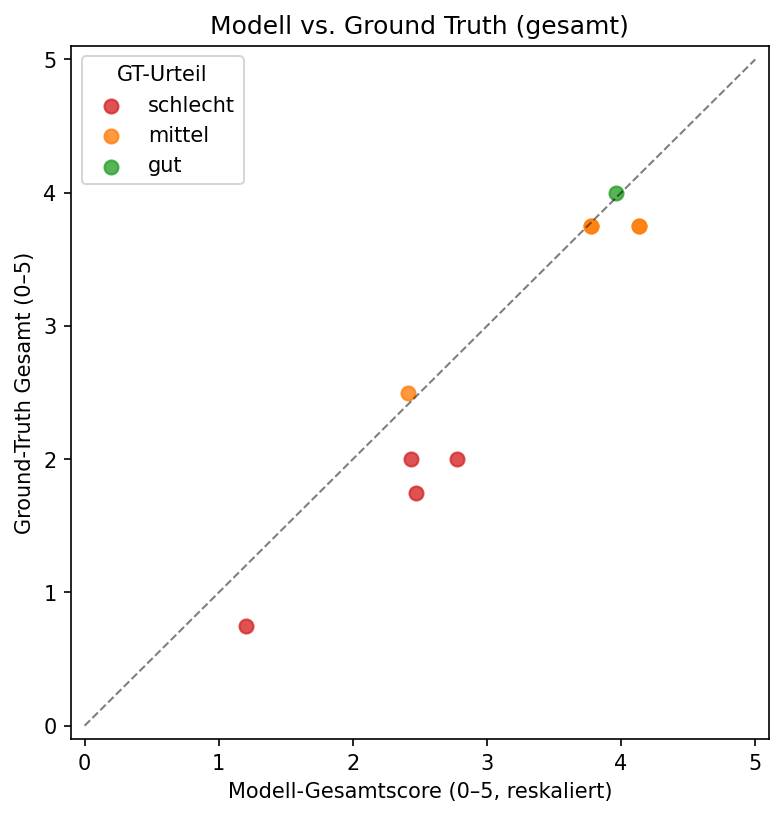

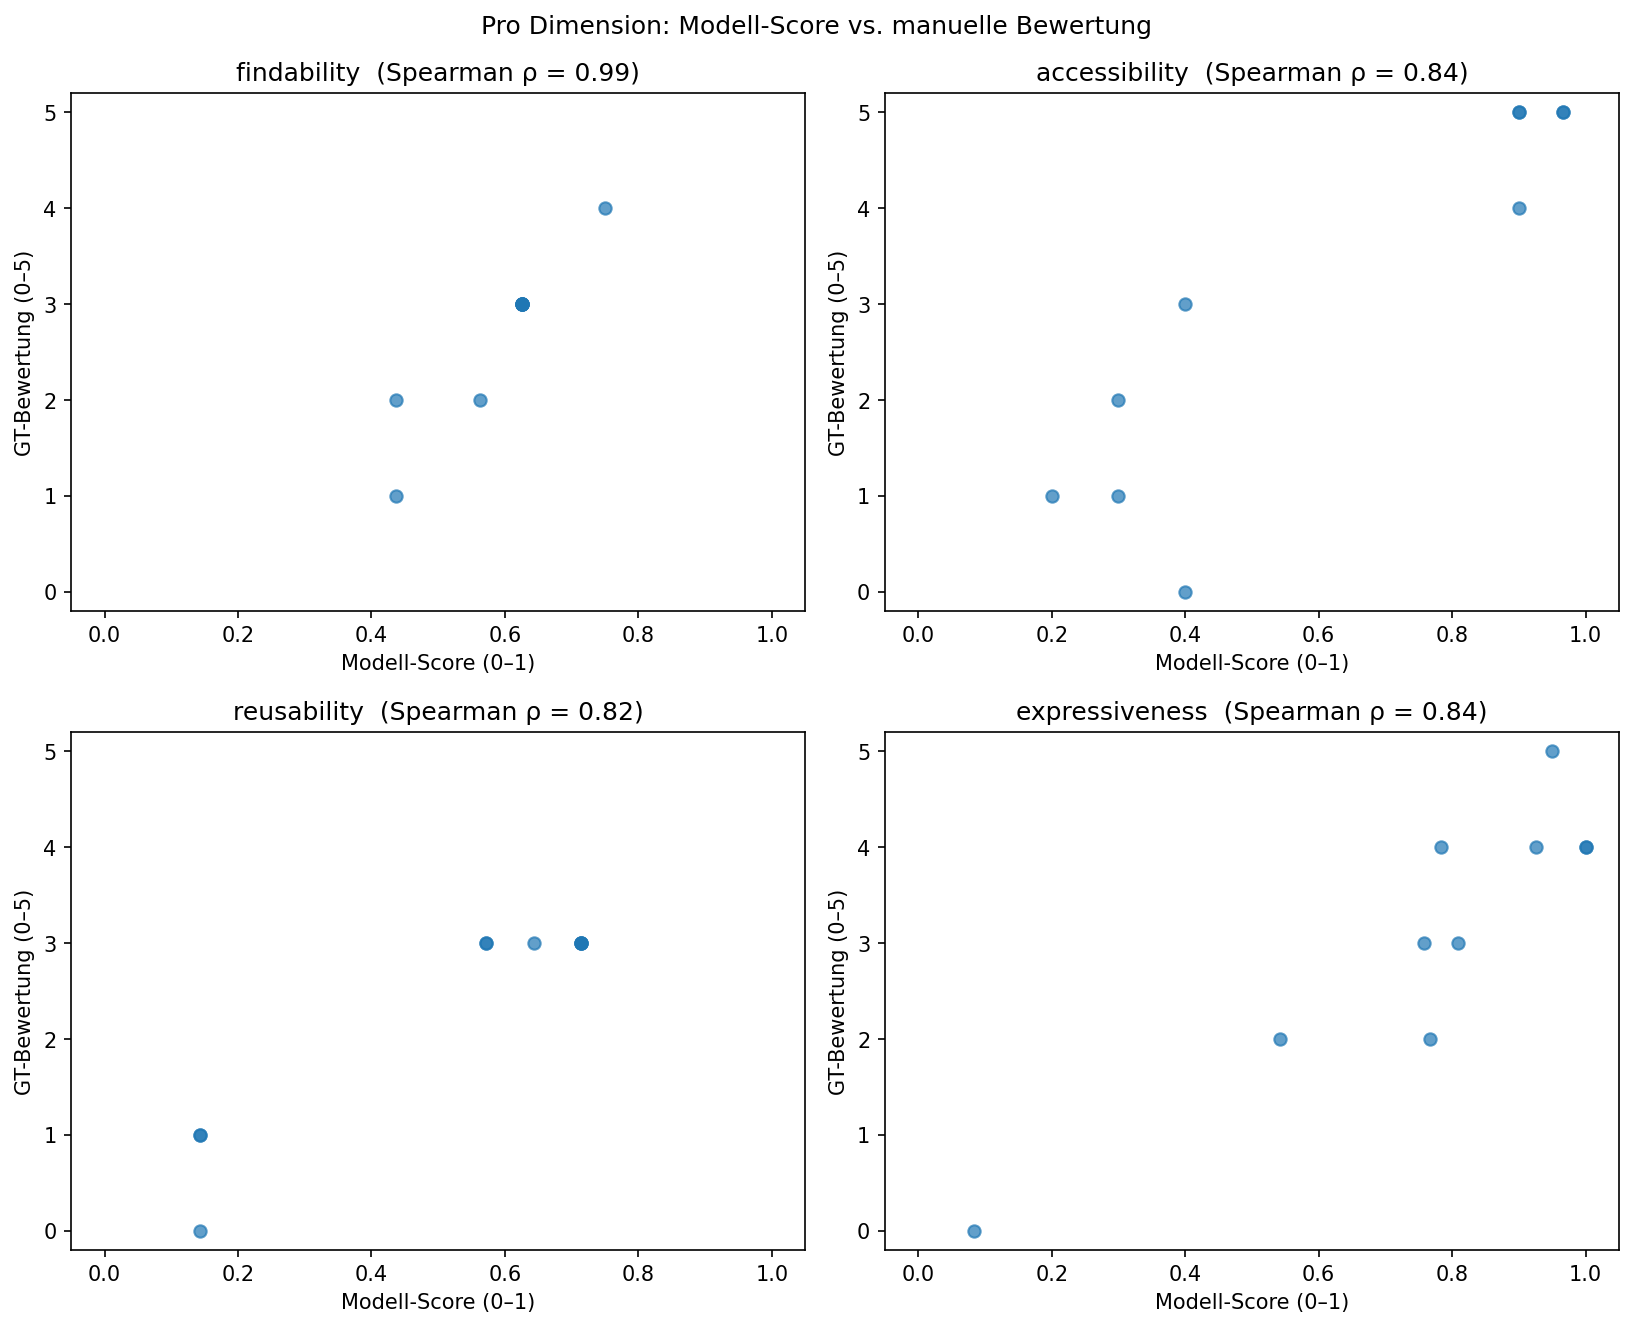

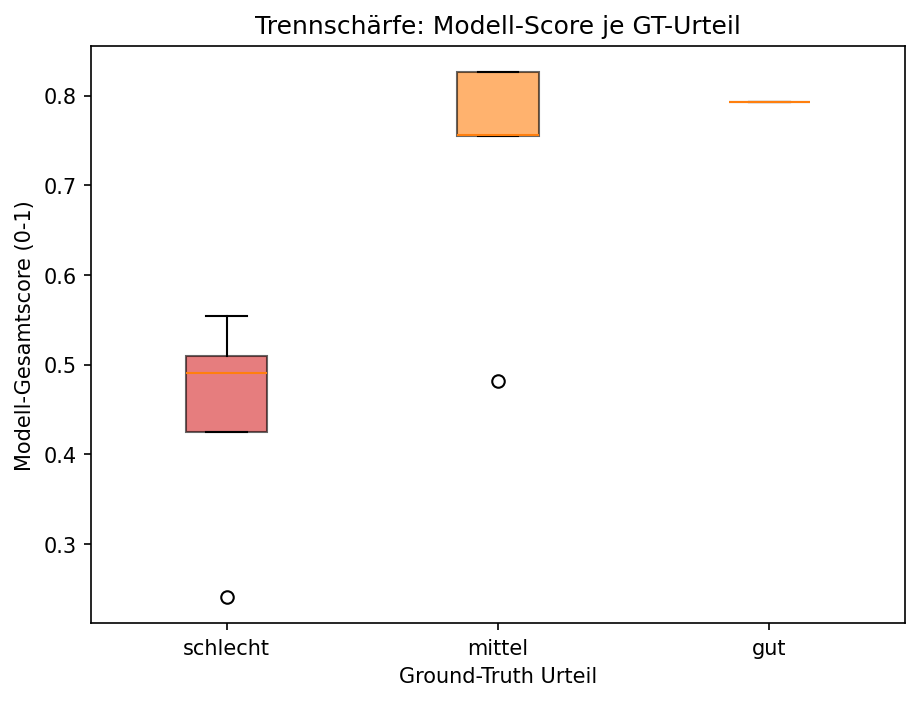

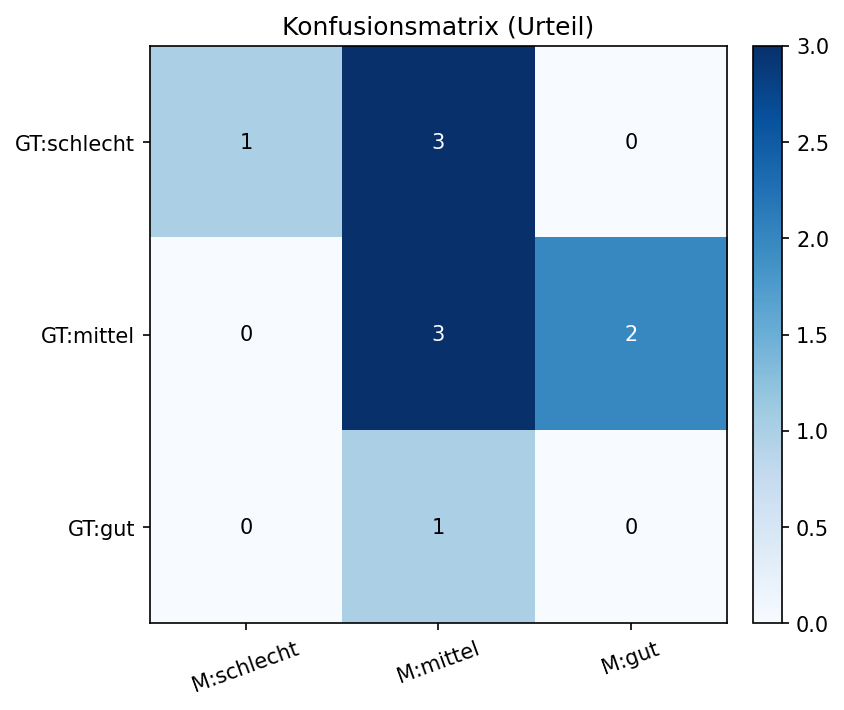

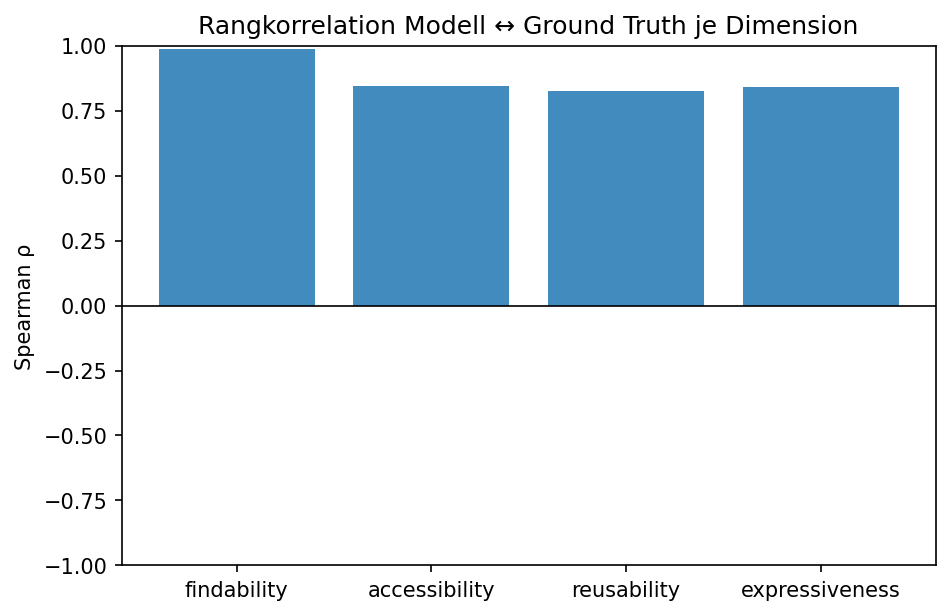

gespeichert:
   /home/lbuerger/masterthesis/master_thesis_prototype/ground_truth_outputs/2026-07-02_13-55-00_figures/overall_scatter.png
   /home/lbuerger/masterthesis/master_thesis_prototype/ground_truth_outputs/2026-07-02_13-55-00_figures/per_dimension_scatter.png
   /home/lbuerger/masterthesis/master_thesis_prototype/ground_truth_outputs/2026-07-02_13-55-00_figures/separation_boxplot.png
   /home/lbuerger/masterthesis/master_thesis_prototype/ground_truth_outputs/2026-07-02_13-55-00_figures/confusion_matrix.png
   /home/lbuerger/masterthesis/master_thesis_prototype/ground_truth_outputs/2026-07-02_13-55-00_figures/spearman_per_dimension.png


In [64]:
if result is not None:
    paths = gt.make_figures(merged, result, FIG_DIR)
    for p in paths:
        display(Image(str(p)))
    print('gespeichert:')
    for p in paths:
        print('  ', p)
else:
    print('Übersprungen — keine Bewertungen.')

## 5. Getrennt: Kernstichprobe vs. Extremfälle

Laut Methodik werden Kernstichprobe und Extremfälle **getrennt** ausgewertet. Dazu dieses Notebook ein zweites Mal mit `SAMPLE_DIR = REPO/'data'/'extreme_cases'` (bzw. dem Extremfall-Verzeichnis) laufen lassen — dort ebenfalls vorher ein `ground_truth_template.csv` via `scripts/build_ground_truth_template.py <dir>` erzeugen und bewerten.

Optional lassen sich beide Ergebnis-Tabellen am Ende nebeneinanderstellen (z. B. `pd.concat` der jeweiligen `summary_table`).